# Employment Stability of Workers 55+

**Jana Dolečková** · Data Analyst
- Research direction
- Data source selection
- Review and interpretation

**Claude** (Anthropic AI assistant)
- Data collection
- Code
- Chart generation
- Presentation design and build

**Goal:** Highlight the stability of employees aged 55+. This analysis is built primarily on U.S. data, examining job tenure (how long someone stays with the same employer, not to be confused with academic tenure) by age and education. A secondary comparison is then run against the best available Czech data, though it is considerably less detailed than the U.S. tables.

**Data sources analyzed here:**
- U.S. Bureau of Labor Statistics (BLS) - [Employee Tenure Summary, January 2024](https://www.bls.gov/news.release/tenure.t01.htm) - the most detailed publicly available data linking tenure with both age *and* education (primary analysis)
- Eurostat / Czech Statistical Office - [lfsa_egad, Employed persons by job tenure](https://ec.europa.eu/eurostat/databrowser/view/lfsa_egad/default/table), data for the Czech Republic, 2025 (secondary comparison, less granular)

**Note on data choice:** The analysis was originally meant to be built on a synthetic Kaggle employee-attrition dataset. After checking correlations (age vs. attrition: r = 0.008; age vs. salary: r = -0.003), it turned out to be purely randomly generated data with no built-in relationship between variables - no honest conclusion could be drawn from it. I switched to real, publicly published data from BLS and Eurostat instead.

**Note on notebook structure:** Each chart is built in two visible steps: a filter cell showing the exact rows selected, then a plotting cell that charts them. Sections with U.S. (BLS) data include a short comment on what the chart shows; sections with Czech/European (Eurostat) data include only factual observations (the numbers and their scale) - no speculation about *why* a pattern exists.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
DATA_DIR = "../data/bls"
EU_DATA_DIR = "../data/eurostat_cz"
OUT_DIR = "../visuals"

COLOR_PRIMARY = "#2C6E49"     # green - 55+ stability
COLOR_SECONDARY = "#6FAE8C"   # medium green - accent
COLOR_MUTED = "#B8DCC9"       # light green - younger cohorts / context

BLUE_PRIMARY = "#2C5F8A"      # blue - non-age dimension (education / sex / duration)
BLUE_SECONDARY = "#6F97C4"    # medium blue
BLUE_MUTED = "#B8CEE8"        # light blue

CZ_PRIMARY = "#7A4F26"        # amber/brown - Czech Republic (secondary comparison)
CZ_SECONDARY = "#C99A5C"      # medium amber
CZ_MUTED = "#E8D2AE"          # light tan

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


## 1. Loading the data

In [2]:
tenure_age_sex = pd.read_csv(f"{DATA_DIR}/tenure_by_age_sex_2014_2024.csv")
tenure_edu_age = pd.read_csv(f"{DATA_DIR}/tenure_by_education_age_2024.csv")
tenure_dist = pd.read_csv(f"{DATA_DIR}/tenure_distribution_by_age_2024.csv")
cz_tenure = pd.read_csv(f"{EU_DATA_DIR}/cz_job_tenure_2025.csv")

tenure_age_sex.head()


,age_group,sex,year_2014,year_2016,year_2018,year_2020,year_2022,year_2024
0,16 and over,Total,4.6,4.2,4.2,4.1,4.1,3.9
1,16 to 17,Total,0.7,0.6,0.6,0.7,0.7,0.7
2,18 to 19,Total,0.8,0.8,0.8,0.8,0.7,0.9
3,20 to 24,Total,1.3,1.3,1.2,1.3,1.2,1.4
4,25 and over,Total,5.5,5.1,5.0,4.9,4.9,4.8


## 2. Data quality check

The data comes directly from official BLS and Eurostat tables (Current Population Survey / EU Labour Force Survey) - it's already aggregated, published statistics, not raw individual-level data. So there's no missing-value or outlier handling here; we just confirm the columns match expectations.

In [3]:
print(tenure_age_sex.shape, tenure_edu_age.shape, tenure_dist.shape, cz_tenure.shape)
print(cz_tenure.dtypes)


(22, 8) (19, 8) (8, 9) (16, 6)
sex              object
age_group        object
pct_0_11m       float64
pct_12_23m      float64
pct_24_59m      float64
pct_60m_plus    float64
dtype: object


## 3. USA - does job tenure change with age?

**Query:** we select rows for `sex == 'Total'` (both sexes combined, no education breakdown - this covers all employees) and age groups 25–34 through 65+.

In [4]:
df1 = tenure_age_sex[
    (tenure_age_sex['sex'] == 'Total') &
    (tenure_age_sex['age_group'].isin(['25 to 34', '35 to 44', '45 to 54', '55 to 64', '65 and over']))
].copy()
df1[['age_group', 'year_2024']]


,age_group,year_2024
5,25 to 34,2.7
6,35 to 44,4.6
7,45 to 54,7.0
8,55 to 64,9.6
9,65 and over,9.8


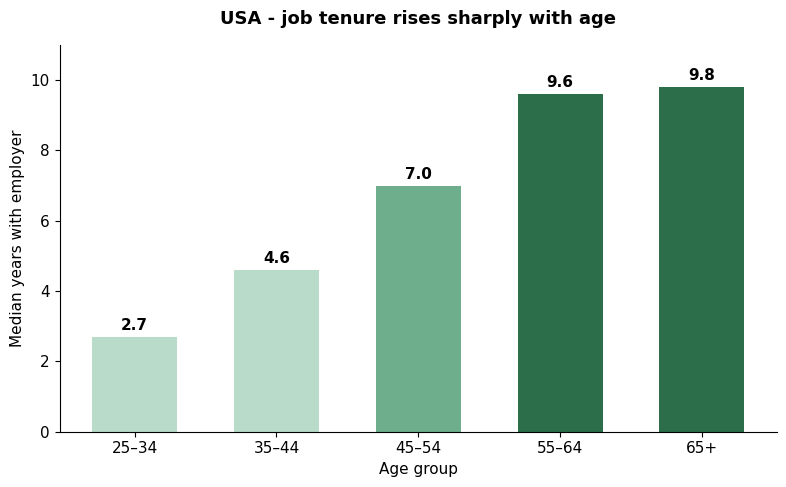

In [5]:
labels_en = {'25 to 34': '25\u201334', '35 to 44': '35\u201344', '45 to 54': '45\u201354',
             '55 to 64': '55\u201364', '65 and over': '65+'}
df1['label'] = df1['age_group'].map(labels_en)
colors = [COLOR_MUTED, COLOR_MUTED, COLOR_SECONDARY, COLOR_PRIMARY, COLOR_PRIMARY]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df1['label'], df1['year_2024'], color=colors, width=0.6)
for bar, val in zip(bars, df1['year_2024']):
    ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 5), ha="center", fontsize=11, fontweight="bold")
ax.set_title("USA - job tenure rises sharply with age", fontsize=13, fontweight="bold", pad=15)
ax.set_ylabel("Median years with employer")
ax.set_xlabel("Age group")
ax.set_ylim(0, 11)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/01_median_tenure_by_age.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Workers aged 55–64 stay with their employer for a median of **9.6 years** - more than **3.5x longer** than workers aged 25–34 (2.7 years).

## 4. USA - is the pattern consistent over time (2014–2024)?

**Query:** same filter as above (`sex == 'Total'`), 3 age groups, all years 2014–2024.

In [6]:
df2 = tenure_age_sex[
    (tenure_age_sex['sex'] == 'Total') &
    (tenure_age_sex['age_group'].isin(['25 to 34', '45 to 54', '55 to 64']))
].copy()
years = [2014, 2016, 2018, 2020, 2022, 2024]
year_cols = [f"year_{y}" for y in years]
df2[['age_group'] + year_cols]


,age_group,year_2014,year_2016,year_2018,year_2020,year_2022,year_2024
5,25 to 34,3.0,2.8,2.8,2.8,2.8,2.7
7,45 to 54,7.9,7.9,7.6,7.5,6.9,7.0
8,55 to 64,10.4,10.1,10.1,9.9,9.8,9.6


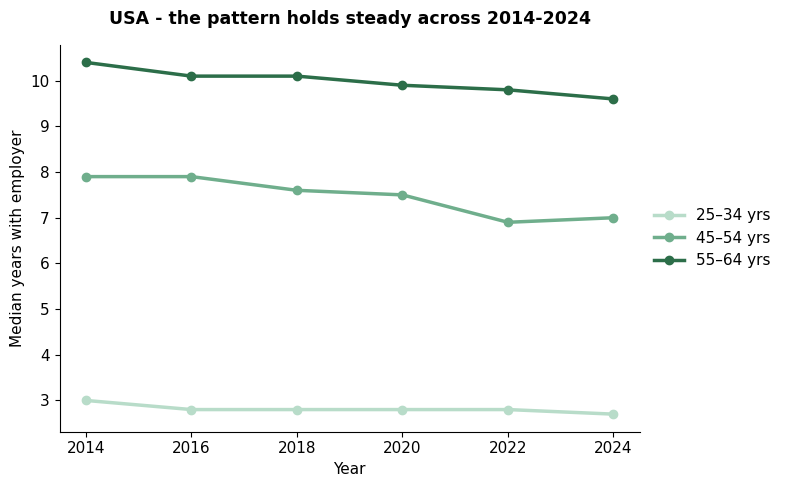

In [7]:
labels_en2 = {'25 to 34': '25\u201334 yrs', '45 to 54': '45\u201354 yrs', '55 to 64': '55\u201364 yrs'}
colors2 = {'25 to 34': COLOR_MUTED, '45 to 54': COLOR_SECONDARY, '55 to 64': COLOR_PRIMARY}

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in df2.iterrows():
    ax.plot(years, row[year_cols].values, marker="o", linewidth=2.5,
            label=labels_en2[row['age_group']], color=colors2[row['age_group']])
ax.set_title("USA - the pattern holds steady across 2014-2024", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("Median years with employer")
ax.set_xlabel("Year")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/02_tenure_trend_2014_2024.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** The gap between age groups is stable across the whole decade - it's not a one-year blip.

## 5. USA - does the pattern hold for college-educated workers too?

**Query:** `sex == 'All'`, education categories: high school only (contrast), bachelor's degree, master's degree.

In [8]:
edu_filter = ['High school graduate no college', "Bachelor's degree only", "Master's degree"]
df3 = tenure_edu_age[
    (tenure_edu_age['sex'] == 'All') &
    (tenure_edu_age['education'].isin(edu_filter))
].copy()
age_cols = ['age_25_34', 'age_35_44', 'age_45_54', 'age_55_64']
df3[['education'] + age_cols]


,education,age_25_34,age_35_44,age_45_54,age_55_64
2,High school graduate no college,2.7,4.6,5.6,9.6
6,Bachelor's degree only,2.8,5.0,7.3,9.4
7,Master's degree,2.9,4.8,9.2,9.9


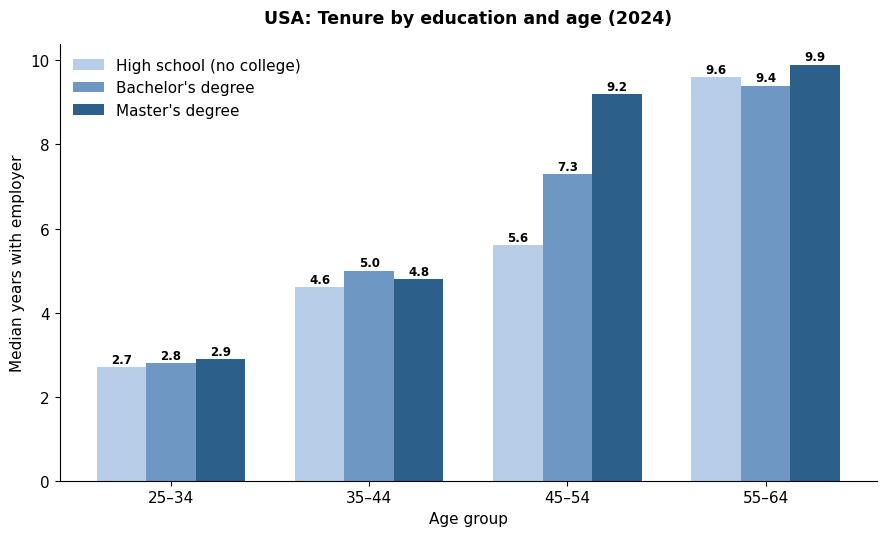

In [9]:
edu_labels = {'High school graduate no college': 'High school (no college)',
              "Bachelor's degree only": "Bachelor's degree", "Master's degree": "Master's degree"}
edu_colors = {'High school graduate no college': BLUE_MUTED,
              "Bachelor's degree only": BLUE_SECONDARY, "Master's degree": BLUE_PRIMARY}
age_labels = ['25\u201334', '35\u201344', '45\u201354', '55\u201364']
x = range(len(age_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, (_, row) in enumerate(df3.iterrows()):
    offsets = [xi + (i - 1) * width for xi in x]
    bars = ax.bar(offsets, row[age_cols].values, width=width, label=edu_labels[row['education']], color=edu_colors[row['education']])
    for bar, val in zip(bars, row[age_cols].values):
        ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8.5, fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(age_labels)
ax.set_title("USA: Tenure by education and age (2024)", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("Median years with employer")
ax.set_xlabel("Age group")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/03_tenure_by_education_age.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Even among college-educated workers, tenure still rises sharply with age. Focusing on master's degree holders specifically: at 45–54 they have a median of 9.2 years with their employer, versus just 2.9 years for master's degree holders aged 25–34 - the same steep age pattern seen across the whole population, not something limited to less-educated workers.

## 5b. USA - college graduates: how does tenure vary across all age decades?

**Query:** `education == 'College graduates (all)'`, `sex == 'All'`, all age groups including 65+.

In [10]:
df3b = tenure_edu_age[
    (tenure_edu_age['sex'] == 'All') &
    (tenure_edu_age['education'] == 'College graduates (all)')
].copy()
age_cols_full = ['age_25_34', 'age_35_44', 'age_45_54', 'age_55_64', 'age_65_plus']
df3b[['education'] + age_cols_full]


,education,age_25_34,age_35_44,age_45_54,age_55_64,age_65_plus
5,College graduates (all),2.8,4.9,7.9,9.7,9.9


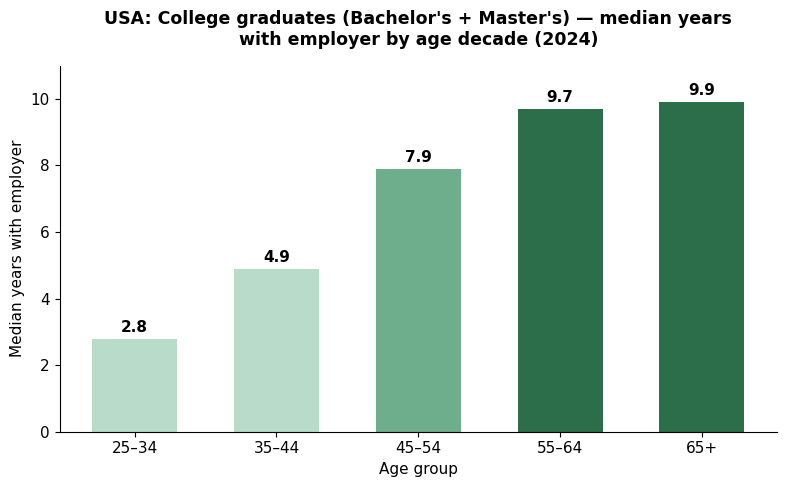

In [11]:
age_labels_full = ['25\u201334', '35\u201344', '45\u201354', '55\u201364', '65+']
values = df3b[age_cols_full].values[0]
colors3b = [COLOR_MUTED, COLOR_MUTED, COLOR_SECONDARY, COLOR_PRIMARY, COLOR_PRIMARY]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_labels_full, values, color=colors3b, width=0.6)
for bar, val in zip(bars, values):
    ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 5), ha="center", fontsize=11, fontweight="bold")
ax.set_title("USA: College graduates (Bachelor's + Master's) \u2014 median years\nwith employer by age decade (2024)", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("Median years with employer")
ax.set_xlabel("Age group")
ax.set_ylim(0, 11)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/03b_college_grads_all_ages.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** College graduates aged 55–64 have a median of 9.7 years with their employer, 3.5x more than 25–34 year-old graduates (2.8 years). Note: this is a cross-section of different people in 2024, not one person's timeline.

## 5c. USA - does the pattern differ by sex among college graduates?

**Query:** `sex.isin(['Men','Women'])`, `education.isin(["Bachelor's degree only","Master's degree"])`. No interpretation - data only.

In [12]:
df3c = tenure_edu_age[
    (tenure_edu_age['sex'].isin(['Men', 'Women'])) &
    (tenure_edu_age['education'].isin(["Bachelor's degree only", "Master's degree"]))
].copy()
df3c[['education', 'sex'] + age_cols]


,education,sex,age_25_34,age_35_44,age_45_54,age_55_64
11,Bachelor's degree only,Men,3.0,5.5,7.8,10.0
12,Master's degree,Men,2.8,4.8,9.2,10.1
16,Bachelor's degree only,Women,2.6,4.5,6.6,8.2
17,Master's degree,Women,3.0,4.7,9.2,9.5


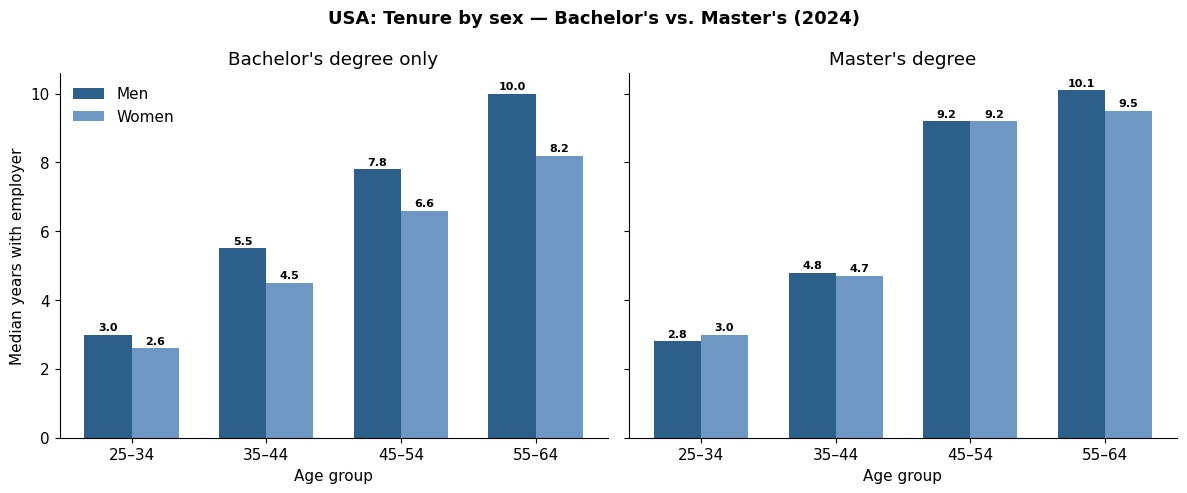

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, edu in zip(axes, ["Bachelor's degree only", "Master's degree"]):
    sub = df3c[df3c['education'] == edu]
    width = 0.35
    xpos = range(len(age_labels))
    for i, sex in enumerate(['Men', 'Women']):
        row = sub[sub['sex'] == sex][age_cols].values[0]
        offsets = [xi + (i - 0.5) * width for xi in xpos]
        color = BLUE_PRIMARY if sex == 'Men' else BLUE_SECONDARY
        bars = ax.bar(offsets, row, width=width, label=sex, color=color)
        for bar, val in zip(bars, row):
            ax.annotate(f"{val:.1f}", (bar.get_x() + bar.get_width() / 2, val),
                        textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8, fontweight="bold")
    ax.set_xticks(list(xpos))
    ax.set_xticklabels(age_labels)
    ax.set_title(edu)
    ax.set_xlabel("Age group")
axes[0].set_ylabel("Median years with employer")
axes[0].legend(frameon=False)
fig.suptitle("USA: Tenure by sex \u2014 Bachelor's vs. Master's (2024)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/03c_tenure_by_sex_education.png", dpi=160, bbox_inches="tight")
plt.show()


**Observation:** For bachelor's degree holders, the gap between men and women aged 55–64 is 1.8 years (10.0 vs. 8.2); for master's degree holders it's only 0.6 years (10.1 vs. 9.5). At age 45–54, the gap for master's degree holders is zero (9.2 vs. 9.2). *I must admit I hoped to prove that women are more stable than men - it's a disappointment. On the other hand, it's a good opportunity to demonstrate that I'll stay objective in my analysis, so I'll keep it there :)*

## 6. USA - how does the share of short-tenure vs. long-tenure employees change with age?

**Query:** `tenure_dist` is broken down by age only (no education - BLS doesn't publish that combination), we exclude only the summary `Total` row.

In [14]:
df4 = tenure_dist[tenure_dist['age_group'] != 'Total'].copy()
labels_en4 = {'16 to 19': '16\u201319', '20 to 24': '20\u201324', '25 to 34': '25\u201334',
              '35 to 44': '35\u201344', '45 to 54': '45\u201354', '55 to 64': '55\u201364', '65 and over': '65+'}
df4['label'] = df4['age_group'].map(labels_en4)
df4[['label', 'pct_12m_or_less']]


,label,pct_12m_or_less
1,16–19,70.3
2,20–24,48.3
3,25–34,28.1
4,35–44,17.5
5,45–54,12.6
6,55–64,9.6
7,65+,10.5


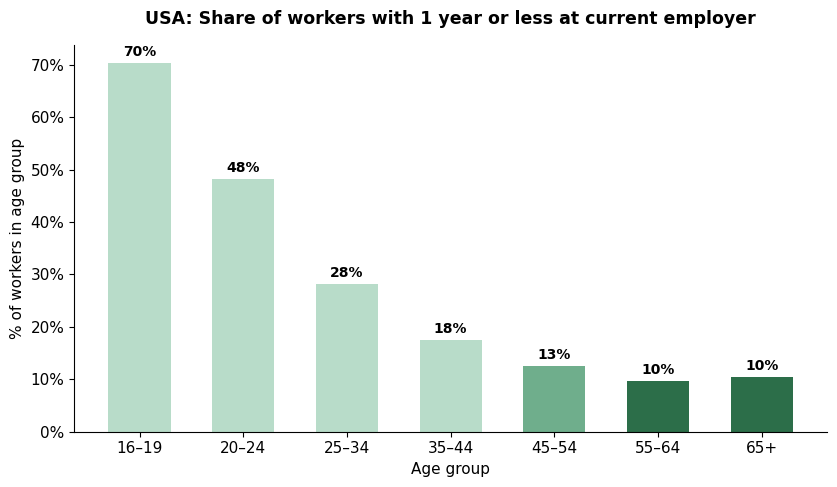

In [15]:
colors4 = [COLOR_MUTED] * 4 + [COLOR_SECONDARY, COLOR_PRIMARY, COLOR_PRIMARY]
fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(df4['label'], df4['pct_12m_or_less'], color=colors4, width=0.6)
for bar, val in zip(bars, df4['pct_12m_or_less']):
    ax.annotate(f"{val:.0f}%", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 5), ha="center", fontsize=10, fontweight="bold")
ax.set_title("USA: Share of workers with 1 year or less at current employer", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("% of workers in age group")
ax.set_xlabel("Age group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/04_short_tenure_share_by_age.png", dpi=160, bbox_inches="tight")
plt.show()


**Finding:** Only **10%** of workers aged 55–64 started their current job in the past year (vs. **48%** for the 20–24 group).

In [16]:
df4['pct_10y_plus'] = df4['pct_10_14y'] + df4['pct_15_19y'] + df4['pct_20y_plus']
df4[['label', 'pct_10y_plus']]


,label,pct_10y_plus
1,16–19,0.0
2,20–24,0.2
3,25–34,5.8
4,35–44,25.3
5,45–54,41.8
6,55–64,50.6
7,65+,51.7


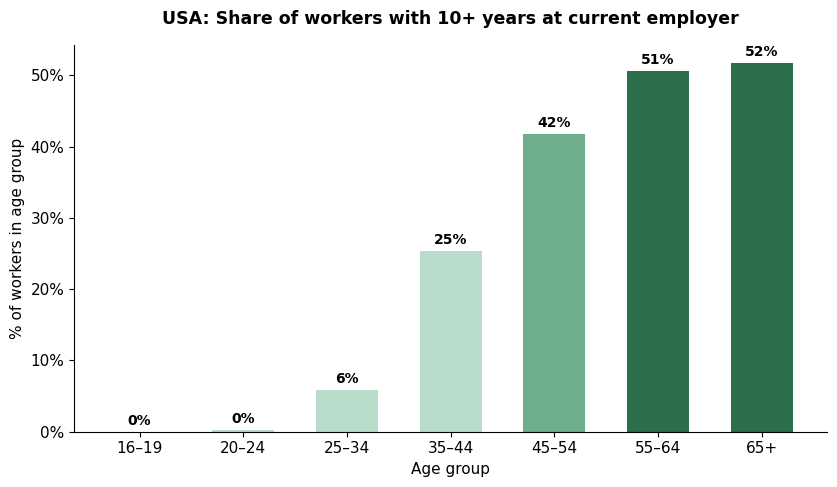

In [17]:
colors5 = [COLOR_MUTED] * 4 + [COLOR_SECONDARY, COLOR_PRIMARY, COLOR_PRIMARY]
fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(df4['label'], df4['pct_10y_plus'], color=colors5, width=0.6)
for bar, val in zip(bars, df4['pct_10y_plus']):
    ax.annotate(f"{val:.0f}%", (bar.get_x() + bar.get_width() / 2, val),
                textcoords="offset points", xytext=(0, 5), ha="center", fontsize=10, fontweight="bold")
ax.set_title("USA: Share of workers with 10+ years at current employer", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("% of workers in age group")
ax.set_xlabel("Age group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/05_long_tenure_share_by_age.png", dpi=160, bbox_inches="tight")
plt.show()


Conversely, **51%** of workers aged 55–64 have already been with their employer 10+ years (vs. 6% for the 25–34 group).

Note: BLS doesn't publish this tenure-band breakdown (0–1 year, 10+ years) cross-tabulated by education - only by age. The age × education cross-tab BLS does publish is median years (used in sections 5, 5b, 5c above), which is why we can't recreate this specific chart for college graduates only.

## 7. Czech Republic - secondary comparison: does the same pattern appear in Europe (2025)?

This section is a secondary comparison against the primary U.S. analysis above - the Eurostat data available here is considerably less granular (duration bands rather than a median, no education breakdown).

Source: Eurostat table `lfsa_egad` ("Employed persons by job tenure"), Czech Republic data collected via the Labour Force Survey (LFS), 2025 - the most recent year available. Unlike BLS, this isn't a median in years but a breakdown into duration bands (0–11 months, 12–23, 24–59, 60+ months).

**Note on age groups:** Eurostat only publishes overlapping age bands for this table (e.g. "25 years or over" includes everyone 50+ too, so it can't sit next to "50–64" as a fair comparison). To get a clean, non-overlapping **25–49** group, we derived it ourselves: Eurostat also publishes the underlying headcounts (in thousands), so 25–49 = (25 years or over) minus (50 years or over), computed on the absolute counts per duration band, then turned back into percentages. The 15–24 group was dropped from this chart since it's dominated by student/part-time jobs, which aren't comparable to the rest.

No interpretation, just data and charts - draw your own conclusions.

**Query:** `sex == 'Total'`, ages 25–49 (derived), 50–64, 65+.

In [18]:
cz_total = cz_tenure[cz_tenure['sex'] == 'Total'].copy()
cz_total


,sex,age_group,pct_0_11m,pct_12_23m,pct_24_59m,pct_60m_plus
0,Total,15-24,35.5,23.7,29.0,7.8
1,Total,25+,7.2,6.0,14.3,69.0
2,Total,25-49,9.0,7.6,17.9,62.1
3,Total,50-64,4.0,3.4,8.6,80.3
4,Total,50-74,4.3,3.4,8.6,79.9
5,Total,65+,6.8,4.7,7.4,76.2


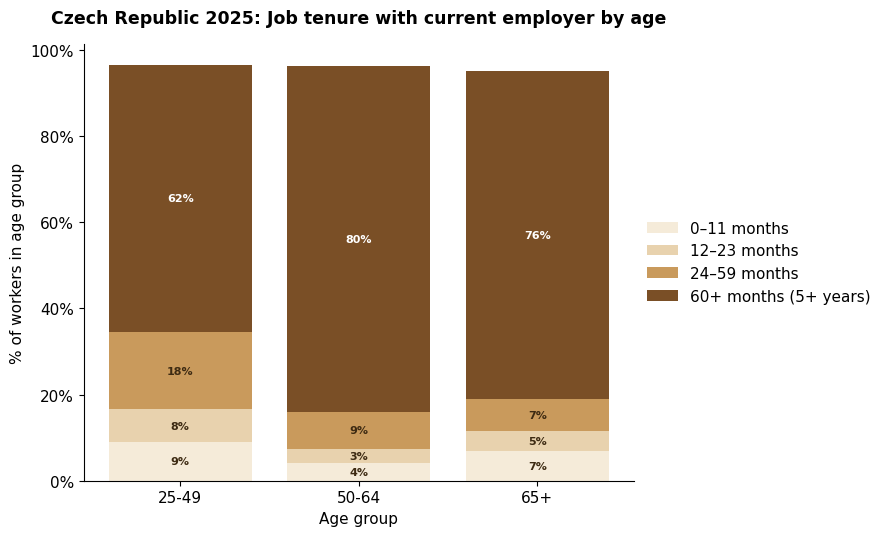

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
age_order = ['25-49', '50-64', '65+']
cz_plot = cz_total.set_index('age_group').loc[age_order]
bottom = pd.Series([0]*len(cz_plot), index=cz_plot.index, dtype=float)
segments = [('pct_0_11m', '0\u201311 months', '#F5EBD9'),
            ('pct_12_23m', '12\u201323 months', CZ_MUTED),
            ('pct_24_59m', '24\u201359 months', CZ_SECONDARY),
            ('pct_60m_plus', '60+ months (5+ years)', CZ_PRIMARY)]
for col, label, color in segments:
    bars = ax.bar(cz_plot.index, cz_plot[col], bottom=bottom, label=label, color=color)
    text_color = "white" if color == CZ_PRIMARY else "#3D2A12"
    for bar, val, b in zip(bars, cz_plot[col], bottom):
        ax.annotate(f"{val:.0f}%", (bar.get_x() + bar.get_width() / 2, b + val / 2),
                    ha="center", va="center", fontsize=8, fontweight="bold", color=text_color)
    bottom += cz_plot[col]
ax.set_title("Czech Republic 2025: Job tenure with current employer by age", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("% of workers in age group")
ax.set_xlabel("Age group")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/07_cz_tenure_by_age_2025.png", dpi=160, bbox_inches="tight")
plt.show()


The Czech data confirms the same pattern seen in the U.S.: tenure rises with age, from 62.1% of 25–49 year-olds with 5+ years at their employer to 80.3% for 50–64 year-olds and 76.2% for 65+.

**Note:** the four duration bands don't sum to exactly 100% (e.g. 96.6% for the 25–49 group) - the remaining few percent is Eurostat's not-stated/unknown-duration share, which isn't published as a separate column in this extract.

**Query:** `sex.isin(['Men','Women'])`, share with 60+ months (5+ years) with employer by age.

In [20]:
cz_sex = cz_tenure[cz_tenure['sex'].isin(['Men', 'Women']) & cz_tenure['age_group'].isin(['25-49', '50-64', '65+'])].copy()
cz_sex[['sex', 'age_group', 'pct_60m_plus']]


,sex,age_group,pct_60m_plus
8,Men,25-49,66.6
9,Men,50-64,82.3
10,Men,65+,78.0
13,Women,25-49,56.7
14,Women,50-64,78.2
15,Women,65+,73.9


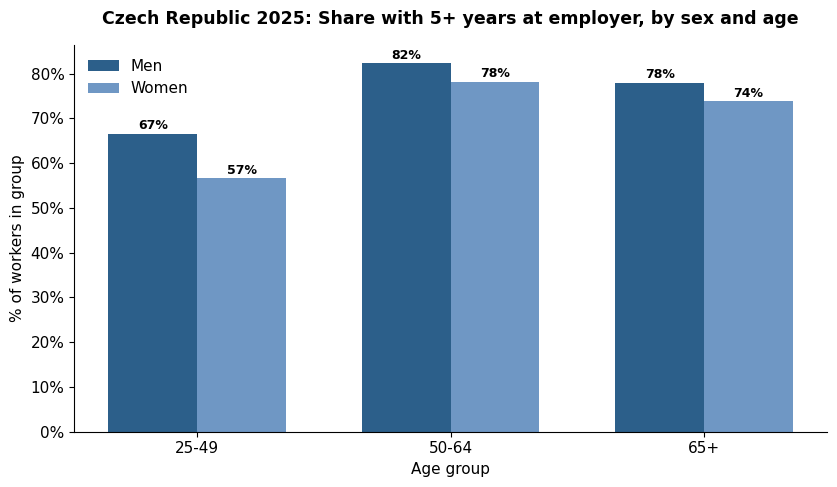

In [21]:
age_order2 = ['25-49', '50-64', '65+']
fig, ax = plt.subplots(figsize=(8.5, 5))
width = 0.35
xpos = range(len(age_order2))
for i, sex in enumerate(['Men', 'Women']):
    vals = [cz_sex[(cz_sex['sex'] == sex) & (cz_sex['age_group'] == a)]['pct_60m_plus'].values[0] for a in age_order2]
    offsets = [xi + (i - 0.5) * width for xi in xpos]
    color = BLUE_PRIMARY if sex == 'Men' else BLUE_SECONDARY
    bars = ax.bar(offsets, vals, width=width, label=sex, color=color)
    for bar, val in zip(bars, vals):
        ax.annotate(f"{val:.0f}%", (bar.get_x() + bar.get_width() / 2, val),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(list(xpos))
ax.set_xticklabels(age_order2)
ax.set_title("Czech Republic 2025: Share with 5+ years at employer, by sex and age", fontsize=12.5, fontweight="bold", pad=15)
ax.set_ylabel("% of workers in group")
ax.set_xlabel("Age group")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/08_cz_tenure_by_sex_age_2025.png", dpi=160, bbox_inches="tight")
plt.show()


Neither are Czech women more stable at their job than men, but at least the difference isn't so pronounced :) Men have a higher share with 5+ years' tenure in every age group, though the gap narrows sharply from 25–49 (67% vs. 57%) to 50–64 and 65+ (both around 4 points).

## 8. Summary

**United States (primary analysis)**

1. Median tenure with an employer rises almost monotonically with age - from 2.7 years (25–34) to 9.6–9.8 years (55+). The trend is stable over time (2014–2024).
2. This also holds for college-educated workers - college graduates 55+ have 3.5x longer tenure than graduates 25–34. There's a gap between men and women, visible in the section 5c chart.
3. Only 10% of workers aged 55–64 are in a job less than a year old, vs. 48% for 20–24 year-olds; 51% have been with their employer 10+ years.

**Czech Republic (secondary comparison)**

4. Czechia 2025 (Eurostat): 80.3% of employed 50–64 year-olds have been with their employer 5+ years, vs. 62.1% for the (derived) 25–49 group - the same general pattern as the U.S. This Eurostat data is considerably less granular than the BLS tables used above (no breakdown by education, broader tenure bands), so it's treated as a supporting comparison, not an equally weighted finding. The gender gap is largest at 25–49 and narrows from 50+.

**Limitations:** BLS and Eurostat data are cross-sectional (one year), not an individual's timeline - you can't claim "today's 55-year-olds churned less when they were 25," only that "today's 55-year-olds churn less than today's 25-year-olds." The Eurostat table doesn't break down by education; the BLS age × education table is U.S.-only. Gaps between men and women are visible in the data, but their causes aren't contained in the data - they're left uninterpreted here.